In [40]:
import os
import glob
import subprocess
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mc
import cartopy.crs as ccrs
from matplotlib.tri import Triangulation

import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 1.5

In [2]:
def haversine(lat0, lon0, lat1, lon1):
    R = 6373.0
    
    lat0 = lat0*np.pi/180.0
    lon0 = np.deg2rad(lon0)
    lat1 = np.deg2rad(lat1)
    lon1 = np.deg2rad(lon1)
    
    d = np.sin((lat1 - lat0)/2)**2 + np.cos(lat0)*np.cos(lat1) * np.sin((lon1 - lon0)/2)**2
    
    return 2 * R * np.arcsin(np.sqrt(d))

### Load CCHaPS data 

In [3]:
# Load CCHaPS lat/lons to choose the closest "wet" grid point:
ds_cchaps = xr.open_dataset('/datasets/work/ev-acs-wp3-cchaps/reference/release/WP3/CSIRO/hindcast/ERA5/BARRA-R2_ORAS5_TPXO_WHACS/BARRA-R2_WHACS/SCHISM-WWMIII-v5.9/national-mesh/1hr/wetdry_node/wetdry_node_cchaps_hindcast_BARRA-R2_WHACS_ERA5_1hr_202001010000-202012312300.nc')
ds_cchaps.close()
lons_cchaps = np.array(ds_cchaps['SCHISM_hgrid_node_x'])
lats_cchaps = np.array(ds_cchaps['SCHISM_hgrid_node_y'])

df_wetdry = pd.read_csv('/datasets/work/oa-roamsurf/work/ech001/CCHaPS_spatial_correlation/maxwetdry_CCHaPS.csv')
wetdry = np.array(df_wetdry['wetdry']).astype(int)

INFO:httpx:HTTP Request: GET https://raw.githubusercontent.com/IrishMarineInstitute/awesome-erddap/master/erddaps.json "HTTP/1.1 200 OK"


### Load wave buoys info

In [92]:
df_buoys = pd.read_csv('/datasets/work/oa-roamsurf/work/ech001/CCHaPS_spatial_correlation/buoy_locations/IMOS_CWB_sites.csv')
state_buoys = np.array(df_buoys['State']).astype(str)

lons_buoys = []
lats_buoys = []
name_buoys = []
for N in range(len(df_buoys)):
    if state_buoys[N] == 'VIC':
        lon_b = float(df_buoys.iloc[N]['Longitude'])
        lat_b = float(df_buoys.iloc[N]['Latitude'])
        
        dist2cchaps = haversine(lats_cchaps, lons_cchaps, lat_b, lon_b)
        dist2cchaps[wetdry!=0] = 1_000_000
        idx = np.argsort(dist2cchaps)[0]
        lats_buoys.append(lats_cchaps[idx])
        lons_buoys.append(lons_cchaps[idx])
        name_buoys.append(df_buoys.iloc[N]['Site Name'].replace(' ', '_'))
lats_buoys = np.array(lats_buoys)
lons_buoys = np.array(lons_buoys)
name_buoys = np.array(name_buoys).astype(str)

<Figure size 640x480 with 0 Axes>

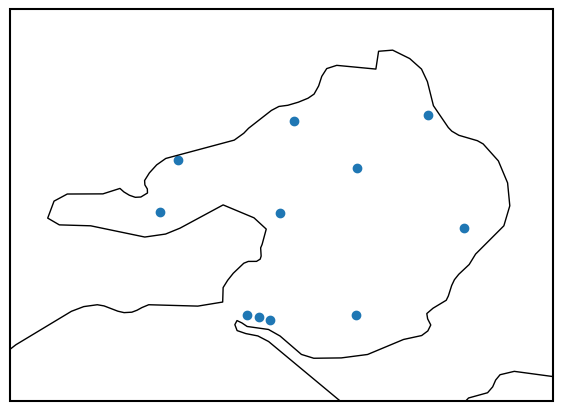

In [93]:
plt.clf()
fig = plt.figure(figsize=(7,7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([144.3, 145.2,-38.45, -37.8])
ax.coastlines('10m')

ax.scatter(lons_buoys, lats_buoys)

### Prepare individual runs for each buoy

In [94]:
# Directory where results will be stored:
workdir = '/datasets/work/oa-roamsurf/work/ech001/CCHaPS_spatial_correlation/VIC/'

# NOTE: You must have spatial_corr_blank.inp, run_code.sh and the compiled programs (spatial_correlation and spatial_correlation_dir) in there
# run_code.sh and spatial_corr_blank.inp are in ./utils

In [97]:
outvars = ['hs', 't02', 'dm']
for outvar in outvars:
    for N in range(len(name_buoys)):
        buoy_dir = os.path.join(workdir, outvar, name_buoys[N])
        if not os.path.exists(buoy_dir):
            os.makedirs(buoy_dir)
        
        subprocess.run(['cp', os.path.join(workdir, 'spatial_corr_blank.inp'), os.path.join(buoy_dir, 'spatial_corr.inp')])
        subprocess.run(['cp', os.path.join(workdir, 'run_code.sh'), os.path.join(buoy_dir, 'run_code.sh')])
        subprocess.run(['sed', '-i', f's/--job-name=corr_/--job-name=r_{outvar}_{name_buoys[N]}/g', os.path.join(buoy_dir, 'run_code.sh')])
        subprocess.run(['sed', '-i', f's/THE_LON/{np.round(lons_buoys[N],5)}/g', os.path.join(buoy_dir, 'spatial_corr.inp')])
        subprocess.run(['sed', '-i', f's/THE_LAT/{np.round(lats_buoys[N],5)}/g', os.path.join(buoy_dir, 'spatial_corr.inp')])
        subprocess.run(['sed', '-i', f's/THE_VAR/{outvar}/g', os.path.join(buoy_dir, 'spatial_corr.inp')])

        if outvar in ['dm','dp']:
            subprocess.run(['cp', os.path.join(workdir, 'spatial_correlation_dir'), os.path.join(buoy_dir, 'spatial_correlation')])
        else:
            subprocess.run(['cp', os.path.join(workdir, 'spatial_correlation'), os.path.join(buoy_dir, 'spatial_correlation')])

In [99]:
# Submit script to launch all jobs
with open(os.path.join(workdir, 'submit_jobs.sh'), 'w') as f:
    for outvar in outvars:
        for N in range(len(name_buoys)):
            buoy_dir = os.path.join(workdir, outvar, name_buoys[N])
            outfiles = glob.glob(os.path.join(buoy_dir, 'schism_corrs_node_*.txt'))
            if len(outfiles)==0:
                f.write(f'cd {buoy_dir} && sbatch run_code.sh \n')

## ***Inspect output***

In [100]:
# (load some coastlines data to make the plots look better)
import geopandas as gpd
gdf = gpd.read_file('/datasets/work/oa-roamsurf/work/ech001/Aus_coastline/AU_NESP-MaC-3-17_AIMS_Aus-Coastline-50k_2024_V1-1.shp')
lons_coast = []
lats_coast = []
extent_reg = [144.3, 145.2,-38.45, -37.8]
lon0, lon1, lat0, lat1 = extent_reg
for T in tqdm(range(len(gdf))):
    lons_tmp, lats_tmp = gdf.iloc[T].geometry.exterior.xy
    lons_tmp = np.array(lons_tmp)
    lats_tmp = np.array(lats_tmp)
    if np.any((lons_tmp>lon0) & (lons_tmp<lon1) & (lats_tmp>lat0) & (lats_tmp<lat1)):
        lons_coast.append(lons_tmp)
        lats_coast.append(lats_tmp)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29760/29760 [00:03<00:00, 8230.86it/s]


In [101]:
ds_cchaps_ref = xr.open_dataset('/datasets/work/ev-acs-wp3-cchaps/reference/release/WP3/CSIRO/hindcast/ERA5/BARRA-R2_ORAS5_TPXO_WHACS/BARRA-R2_WHACS/SCHISM-WWMIII-v5.9/national-mesh/1hr/hs/hs_cchaps_hindcast_BARRA-R2_WHACS_ERA5_1hr_198101010000-198112312300.nc')
ds_cchaps_ref.close()

elems_cchaps = (ds_cchaps_ref.SCHISM_hgrid_face_nodes[:,:-1]).astype(int)
lons_cchaps = ds_cchaps_ref.SCHISM_hgrid_node_x.values
lats_cchaps = ds_cchaps_ref.SCHISM_hgrid_node_y.values
meshtri = Triangulation(lons_cchaps, lats_cchaps, triangles=elems_cchaps)

# Filter CCHaPS grid nodes and elements for PPB
extent_reg = [144.3, 145.2,-38.45, -37.8]
offs=0.1
mask_nodes_reg = (lons_cchaps>extent_reg[0]-offs) & (lons_cchaps<extent_reg[1]+offs) & (lats_cchaps>extent_reg[2]-offs) & (lats_cchaps<extent_reg[3]+offs)
node_idx_map = -np.ones(len(lons_cchaps), dtype=int)
node_idx_map[mask_nodes_reg] = np.arange(np.sum(mask_nodes_reg))
valid_elems = np.all(mask_nodes_reg[elems_cchaps], axis=1)
filt_lons = lons_cchaps[mask_nodes_reg]
filt_lats = lats_cchaps[mask_nodes_reg]
filt_elems = node_idx_map[elems_cchaps[valid_elems]]
meshtri_reg = Triangulation(filt_lons, filt_lats, filt_elems)

In [102]:
outvar = 'dm'
loc = 'Central'

lon_b = lons_buoys[name_buoys==loc]
lat_b = lats_buoys[name_buoys==loc]

corr_file = glob.glob(os.path.join(workdir, outvar, loc, 'schism_corrs_node_*'))[0]
corr_data = np.loadtxt(corr_file)
corr_lons = corr_data[:,0]
corr_lats = corr_data[:,1]
corr_idxs = corr_data[:,2].astype(int)-1
corr_near_buoy = corr_data[:,3]

corr = np.zeros(len(lons_cchaps))
for i in range(len(corr_idxs)):
    corr[corr_idxs[i]] = corr_near_buoy[i]

corr[wetdry!=0]=np.nan

Text(0.5, 1.0, 'dm correlation for buoy=Central')

<Figure size 640x480 with 0 Axes>

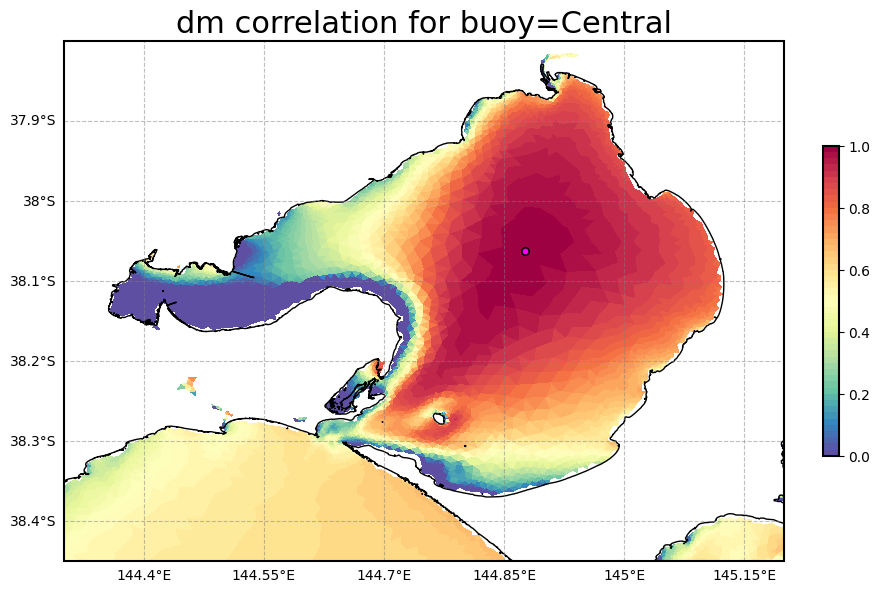

In [103]:
plt.clf()
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
# ax.coastlines('10m')
for i in range(len(lons_coast)):
    ax.plot(lons_coast[i], lats_coast[i], color='black', lw=1.)

ax.set_extent(extent_reg)
gl = ax.gridlines(draw_labels=['bottom', 'left'], ls='--', color='grey', alpha=0.5)

norm = mc.BoundaryNorm(np.linspace(0,1,51), 256)
cax = ax.tripcolor(meshtri_reg, corr[mask_nodes_reg], cmap='Spectral_r', norm=norm, transform=ccrs.PlateCarree())
cbar = fig.colorbar(cax, fraction=0.02, ticks=np.arange(0,1.0001,0.2))
cbar.minorticks_off()
ax.scatter(lon_b, lat_b, marker='o', color='black', s=30, zorder=2, transform=ccrs.PlateCarree())
ax.scatter(lon_b, lat_b, marker='o', color='magenta', s=10, zorder=2, transform=ccrs.PlateCarree())
plt.title(f'{outvar} correlation for buoy={loc}', size=22)

## Max. correlation across buoys

### 1. All buoys except Kirk Point and Clifton Springs

In [134]:
# -------------- Hs ---------------------
corr_hs_buoys = np.zeros([len(corr), len(name_buoys)-2])
c = 0 
for N in range(len(name_buoys)):
    if name_buoys[N] not in ['Kirk_Point', 'Clifton_Springs']:
        corr_files = glob.glob(os.path.join(workdir, 'hs', name_buoys[N], 'schism_corrs_node_*'))
        if len(corr_files)>0:
            corr_file = corr_files[0]
    
            corr_data = np.loadtxt(corr_file)
            corr_lons = corr_data[:,0]
            corr_lats = corr_data[:,1]
            corr_idxs = corr_data[:,2].astype(int)-1
            corr_near_buoy = corr_data[:,3]
            
            corr = np.zeros(len(lons_cchaps))
            for i in range(len(corr_idxs)):
                corr[corr_idxs[i]] = corr_near_buoy[i]
            corr_hs_buoys[:,c] = corr
        else:
            print(f'hs for {name_buoys[c]} not available')
        c = c+1

max_corr_hs = np.nanmax(corr_hs_buoys, axis=1)
max_corr_hs[wetdry!=0]=np.nan

# ---------------- T02 ---------------------
corr_t02_buoys = np.zeros([len(corr), len(name_buoys)-2])
c = 0 
for N in range(len(name_buoys)):
    if name_buoys[N] not in ['Kirk_Point', 'Clifton_Springs']:
        corr_files = glob.glob(os.path.join(workdir, 't02', name_buoys[N], 'schism_corrs_node_*'))
        if len(corr_files)>0:
            corr_file = corr_files[0]
    
            corr_data = np.loadtxt(corr_file)
            corr_lons = corr_data[:,0]
            corr_lats = corr_data[:,1]
            corr_idxs = corr_data[:,2].astype(int)-1
            corr_near_buoy = corr_data[:,3]
            
            corr = np.zeros(len(lons_cchaps))
            for i in range(len(corr_idxs)):
                corr[corr_idxs[i]] = corr_near_buoy[i]
            corr_t02_buoys[:,N] = corr
        else:
            print(f't02 for {name_buoys[N]} not available')
        c = c+1

max_corr_t02 = np.nanmax(corr_t02_buoys, axis=1)
max_corr_t02[wetdry!=0]=np.nan

# ---------------- dm ---------------------
corr_dm_buoys = np.zeros([len(corr), len(name_buoys)-2])
c = 0
for N in range(len(name_buoys)):
    if name_buoys[N] not in ['Kirk_Point', 'Clifton_Springs']:
        corr_files = glob.glob(os.path.join(workdir, 'dm', name_buoys[N], 'schism_corrs_node_*'))
        if len(corr_files)>0:
            corr_file = corr_files[0]
    
            corr_data = np.loadtxt(corr_file)
            corr_lons = corr_data[:,0]
            corr_lats = corr_data[:,1]
            corr_idxs = corr_data[:,2].astype(int)-1
            corr_near_buoy = corr_data[:,3]
            
            corr = np.zeros(len(lons_cchaps))
            for i in range(len(corr_idxs)):
                corr[corr_idxs[i]] = corr_near_buoy[i]
            corr_dm_buoys[:,N] = corr
        else:
            print(f'dm for {name_buoys[N]} not available')
        c = c+1

max_corr_dm = np.nanmax(corr_dm_buoys, axis=1)
max_corr_dm[wetdry!=0]=np.nan

<Figure size 640x480 with 0 Axes>

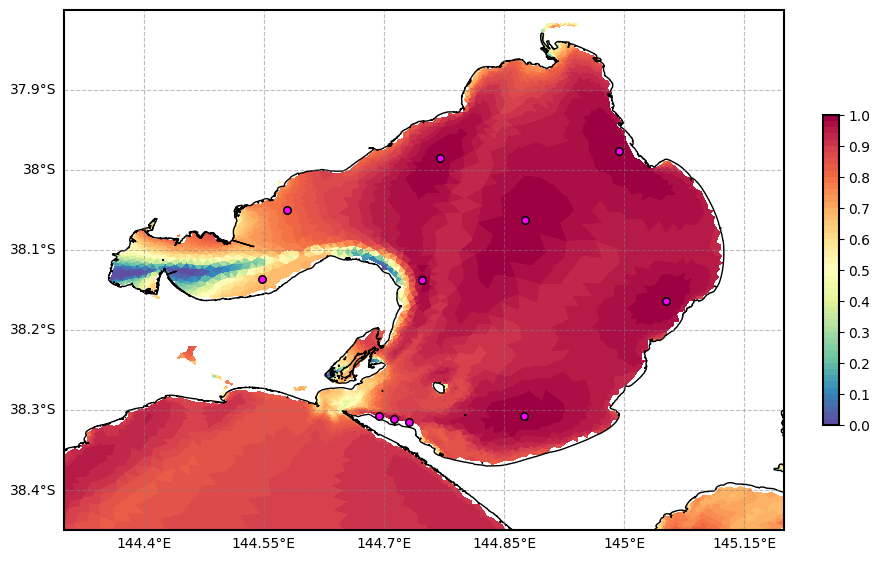

In [135]:
plt.clf()
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
# ax.coastlines('10m')
for i in range(len(lons_coast)):
    ax.plot(lons_coast[i], lats_coast[i], color='black', lw=1.)

ax.set_extent(extent_reg)
gl = ax.gridlines(draw_labels=['bottom', 'left'], ls='--', color='grey', alpha=0.5)

norm = mc.BoundaryNorm(np.linspace(0.,1,51), 256)
cax = ax.tripcolor(meshtri_reg, max_corr_dm[mask_nodes_reg], cmap='Spectral_r', norm=norm, transform=ccrs.PlateCarree())
cbar = fig.colorbar(cax, fraction=0.02, ticks=np.arange(0,1.0001,0.1))
cbar.minorticks_off()
ax.scatter(lons_buoys, lats_buoys, marker='o', color='black', s=30, zorder=2, transform=ccrs.PlateCarree())
ax.scatter(lons_buoys, lats_buoys, marker='o', color='magenta', s=10, zorder=2, transform=ccrs.PlateCarree())
# plt.title(f'{outvar} correlation for buoy={loc}', size=22)

<Figure size 640x480 with 0 Axes>

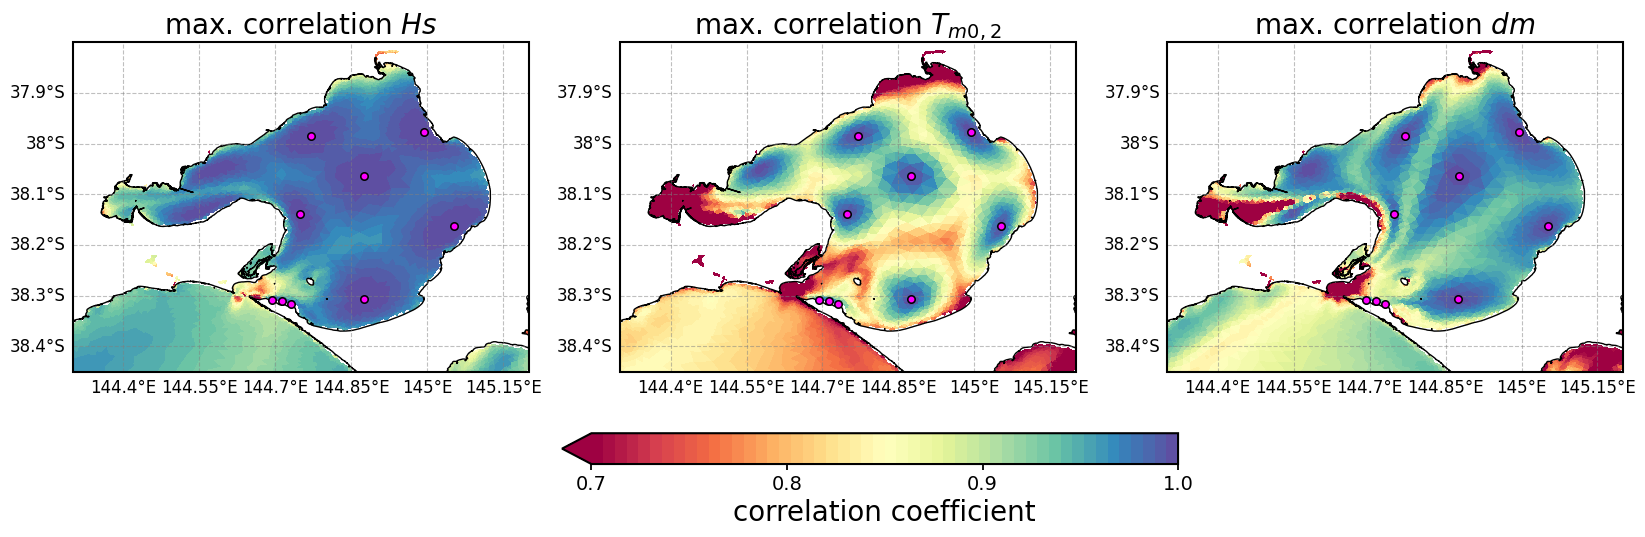

In [152]:
plt.clf()
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,8), subplot_kw={'projection': ccrs.PlateCarree()})
for ax in axs:
    for i in range(len(lons_coast)):
        ax.plot(lons_coast[i], lats_coast[i], color='black', lw=1.)
    ax.set_extent(extent_reg)
    gl = ax.gridlines(draw_labels=['bottom', 'left'], ls='--', color='grey', alpha=0.5)
    gl.xlabel_style = {'size':12}; gl.ylabel_style = {'size':12}
    ax.scatter(lons_buoys[(name_buoys!='Kirk_Point') & (name_buoys!='Clifton_Springs')], lats_buoys[(name_buoys!='Kirk_Point') & (name_buoys!='Clifton_Springs')], 
               marker='o', color='black', s=30, zorder=2, transform=ccrs.PlateCarree())
    ax.scatter(lons_buoys[(name_buoys!='Kirk_Point') & (name_buoys!='Clifton_Springs')], lats_buoys[(name_buoys!='Kirk_Point') & (name_buoys!='Clifton_Springs')], 
               marker='o', color='magenta', s=10, zorder=2, transform=ccrs.PlateCarree())

norm = mc.BoundaryNorm(np.linspace(0.7,1,51), 256)

ax = axs[0]
cax = ax.tripcolor(meshtri_reg, max_corr_hs[mask_nodes_reg], cmap='Spectral', norm=norm, transform=ccrs.PlateCarree())
ax.set_title('max. correlation $Hs$', size=20)

ax = axs[1]
cax = ax.tripcolor(meshtri_reg, max_corr_t02[mask_nodes_reg], cmap='Spectral', norm=norm, transform=ccrs.PlateCarree())
ax.set_title('max. correlation $T_{m0,2}$', size=20)

ax = axs[2]
cax = ax.tripcolor(meshtri_reg, max_corr_dm[mask_nodes_reg], cmap='Spectral', norm=norm, transform=ccrs.PlateCarree())
ax.set_title('max. correlation $dm$', size=20)

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=0.05, pad=0.1, extend='min', ticks=np.arange(0,1.1,0.1))
cbar.set_label('correlation coefficient', size=20)
cbar.minorticks_off()
cbar.ax.tick_params(size=4, width=1.3, labelsize=14)

plt.savefig(os.path.join(workdir, 'max_correlation_current_network.png'), bbox_inches='tight', dpi=300)

### 2. All buoys + Kirk Point

In [142]:
# -------------- Hs ---------------------
corr_hs_buoys = np.zeros([len(corr), len(name_buoys)-1])
c = 0 
for N in range(len(name_buoys)):
    if name_buoys[N] not in ['Clifton_Springs']:
        corr_files = glob.glob(os.path.join(workdir, 'hs', name_buoys[N], 'schism_corrs_node_*'))
        if len(corr_files)>0:
            corr_file = corr_files[0]
    
            corr_data = np.loadtxt(corr_file)
            corr_lons = corr_data[:,0]
            corr_lats = corr_data[:,1]
            corr_idxs = corr_data[:,2].astype(int)-1
            corr_near_buoy = corr_data[:,3]
            
            corr = np.zeros(len(lons_cchaps))
            for i in range(len(corr_idxs)):
                corr[corr_idxs[i]] = corr_near_buoy[i]
            corr_hs_buoys[:,c] = corr
        else:
            print(f'hs for {name_buoys[c]} not available')
        c = c+1

max_corr_hs = np.nanmax(corr_hs_buoys, axis=1)
max_corr_hs[wetdry!=0]=np.nan

# ---------------- T02 ---------------------
corr_t02_buoys = np.zeros([len(corr), len(name_buoys)-1])
c = 0 
for N in range(len(name_buoys)):
    if name_buoys[N] not in ['Clifton_Springs']:
        corr_files = glob.glob(os.path.join(workdir, 't02', name_buoys[N], 'schism_corrs_node_*'))
        if len(corr_files)>0:
            corr_file = corr_files[0]
    
            corr_data = np.loadtxt(corr_file)
            corr_lons = corr_data[:,0]
            corr_lats = corr_data[:,1]
            corr_idxs = corr_data[:,2].astype(int)-1
            corr_near_buoy = corr_data[:,3]
            
            corr = np.zeros(len(lons_cchaps))
            for i in range(len(corr_idxs)):
                corr[corr_idxs[i]] = corr_near_buoy[i]
            corr_t02_buoys[:,N] = corr
        else:
            print(f't02 for {name_buoys[N]} not available')
        c = c+1

max_corr_t02 = np.nanmax(corr_t02_buoys, axis=1)
max_corr_t02[wetdry!=0]=np.nan

# ---------------- dm ---------------------
corr_dm_buoys = np.zeros([len(corr), len(name_buoys)-1])
c = 0
for N in range(len(name_buoys)):
    if name_buoys[N] not in ['Clifton_Springs']:
        corr_files = glob.glob(os.path.join(workdir, 'dm', name_buoys[N], 'schism_corrs_node_*'))
        if len(corr_files)>0:
            corr_file = corr_files[0]
    
            corr_data = np.loadtxt(corr_file)
            corr_lons = corr_data[:,0]
            corr_lats = corr_data[:,1]
            corr_idxs = corr_data[:,2].astype(int)-1
            corr_near_buoy = corr_data[:,3]
            
            corr = np.zeros(len(lons_cchaps))
            for i in range(len(corr_idxs)):
                corr[corr_idxs[i]] = corr_near_buoy[i]
            corr_dm_buoys[:,N] = corr
        else:
            print(f'dm for {name_buoys[N]} not available')
        c = c+1

max_corr_dm = np.nanmax(corr_dm_buoys, axis=1)
max_corr_dm[wetdry!=0]=np.nan

<Figure size 640x480 with 0 Axes>

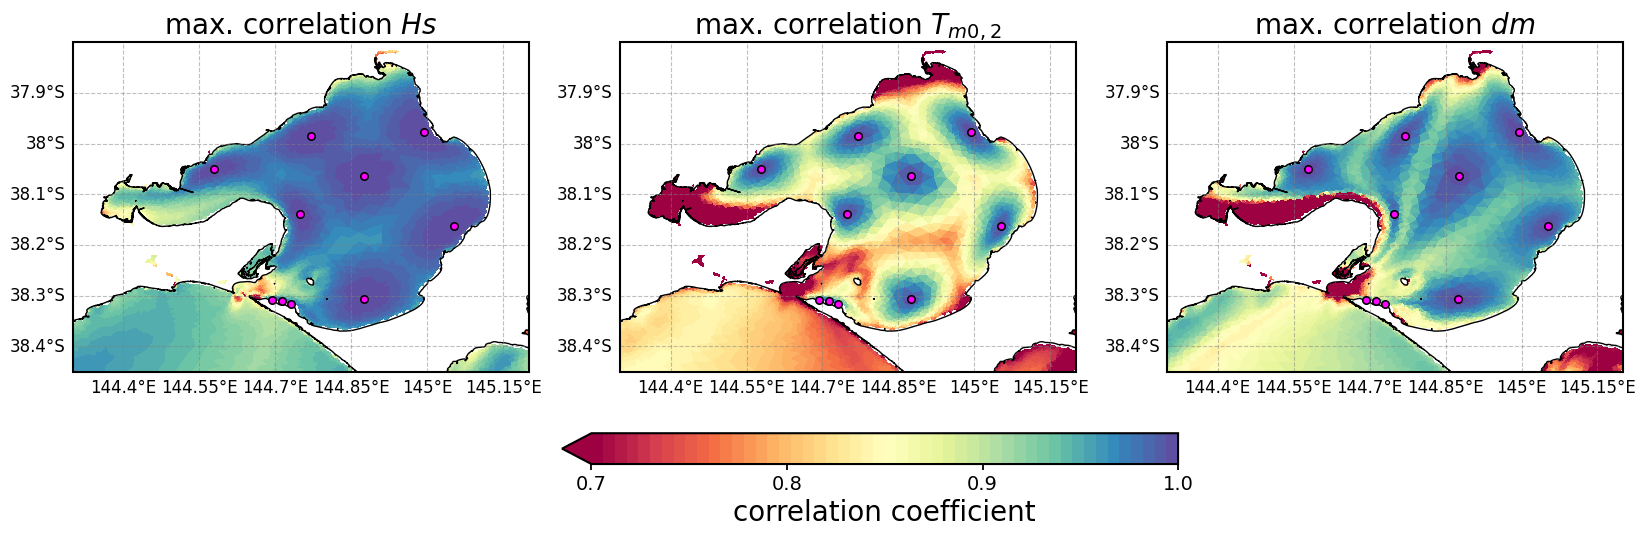

In [143]:
plt.clf()
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,8), subplot_kw={'projection': ccrs.PlateCarree()})
for ax in axs:
    for i in range(len(lons_coast)):
        ax.plot(lons_coast[i], lats_coast[i], color='black', lw=1.)
    ax.set_extent(extent_reg)
    gl = ax.gridlines(draw_labels=['bottom', 'left'], ls='--', color='grey', alpha=0.5)
    gl.xlabel_style = {'size':12}; gl.ylabel_style = {'size':12}
    ax.scatter(lons_buoys[name_buoys!='Clifton_Springs'], lats_buoys[name_buoys!='Clifton_Springs'], 
               marker='o', color='black', s=30, zorder=2, transform=ccrs.PlateCarree())
    ax.scatter(lons_buoys[name_buoys!='Clifton_Springs'], lats_buoys[name_buoys!='Clifton_Springs'], 
               marker='o', color='magenta', s=10, zorder=2, transform=ccrs.PlateCarree())

norm = mc.BoundaryNorm(np.linspace(0.7,1,51), 256)

ax = axs[0]
cax = ax.tripcolor(meshtri_reg, max_corr_hs[mask_nodes_reg], cmap='Spectral', norm=norm, transform=ccrs.PlateCarree())
ax.set_title('max. correlation $Hs$', size=20)

ax = axs[1]
cax = ax.tripcolor(meshtri_reg, max_corr_t02[mask_nodes_reg], cmap='Spectral', norm=norm, transform=ccrs.PlateCarree())
ax.set_title('max. correlation $T_{m0,2}$', size=20)

ax = axs[2]
cax = ax.tripcolor(meshtri_reg, max_corr_dm[mask_nodes_reg], cmap='Spectral', norm=norm, transform=ccrs.PlateCarree())
ax.set_title('max. correlation $dm$', size=20)

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=0.05, pad=0.1, extend='min', ticks=np.arange(0,1.1,0.1))
cbar.set_label('correlation coefficient', size=20)
cbar.minorticks_off()
cbar.ax.tick_params(size=4, width=1.3, labelsize=14)

plt.savefig(os.path.join(workdir, 'max_correlation_current_network_plus_KirkP.png'), bbox_inches='tight', dpi=300)

### 3. All buoys + Kirk Point + Clifton Springs

In [145]:
# -------------- Hs ---------------------
corr_hs_buoys = np.zeros([len(corr), len(name_buoys)])
c = 0 
for N in range(len(name_buoys)):
    corr_files = glob.glob(os.path.join(workdir, 'hs', name_buoys[N], 'schism_corrs_node_*'))
    if len(corr_files)>0:
        corr_file = corr_files[0]

        corr_data = np.loadtxt(corr_file)
        corr_lons = corr_data[:,0]
        corr_lats = corr_data[:,1]
        corr_idxs = corr_data[:,2].astype(int)-1
        corr_near_buoy = corr_data[:,3]
        
        corr = np.zeros(len(lons_cchaps))
        for i in range(len(corr_idxs)):
            corr[corr_idxs[i]] = corr_near_buoy[i]
        corr_hs_buoys[:,c] = corr
    else:
        print(f'hs for {name_buoys[c]} not available')
    c = c+1

max_corr_hs = np.nanmax(corr_hs_buoys, axis=1)
max_corr_hs[wetdry!=0]=np.nan

# ---------------- T02 ---------------------
corr_t02_buoys = np.zeros([len(corr), len(name_buoys)])
c = 0 
for N in range(len(name_buoys)):
    corr_files = glob.glob(os.path.join(workdir, 't02', name_buoys[N], 'schism_corrs_node_*'))
    if len(corr_files)>0:
        corr_file = corr_files[0]

        corr_data = np.loadtxt(corr_file)
        corr_lons = corr_data[:,0]
        corr_lats = corr_data[:,1]
        corr_idxs = corr_data[:,2].astype(int)-1
        corr_near_buoy = corr_data[:,3]
        
        corr = np.zeros(len(lons_cchaps))
        for i in range(len(corr_idxs)):
            corr[corr_idxs[i]] = corr_near_buoy[i]
        corr_t02_buoys[:,N] = corr
    else:
        print(f't02 for {name_buoys[N]} not available')
    c = c+1

max_corr_t02 = np.nanmax(corr_t02_buoys, axis=1)
max_corr_t02[wetdry!=0]=np.nan

# ---------------- dm ---------------------
corr_dm_buoys = np.zeros([len(corr), len(name_buoys)])
c = 0
for N in range(len(name_buoys)):
    corr_files = glob.glob(os.path.join(workdir, 'dm', name_buoys[N], 'schism_corrs_node_*'))
    if len(corr_files)>0:
        corr_file = corr_files[0]

        corr_data = np.loadtxt(corr_file)
        corr_lons = corr_data[:,0]
        corr_lats = corr_data[:,1]
        corr_idxs = corr_data[:,2].astype(int)-1
        corr_near_buoy = corr_data[:,3]
        
        corr = np.zeros(len(lons_cchaps))
        for i in range(len(corr_idxs)):
            corr[corr_idxs[i]] = corr_near_buoy[i]
        corr_dm_buoys[:,N] = corr
    else:
        print(f'dm for {name_buoys[N]} not available')
    c = c+1

max_corr_dm = np.nanmax(corr_dm_buoys, axis=1)
max_corr_dm[wetdry!=0]=np.nan

<Figure size 640x480 with 0 Axes>

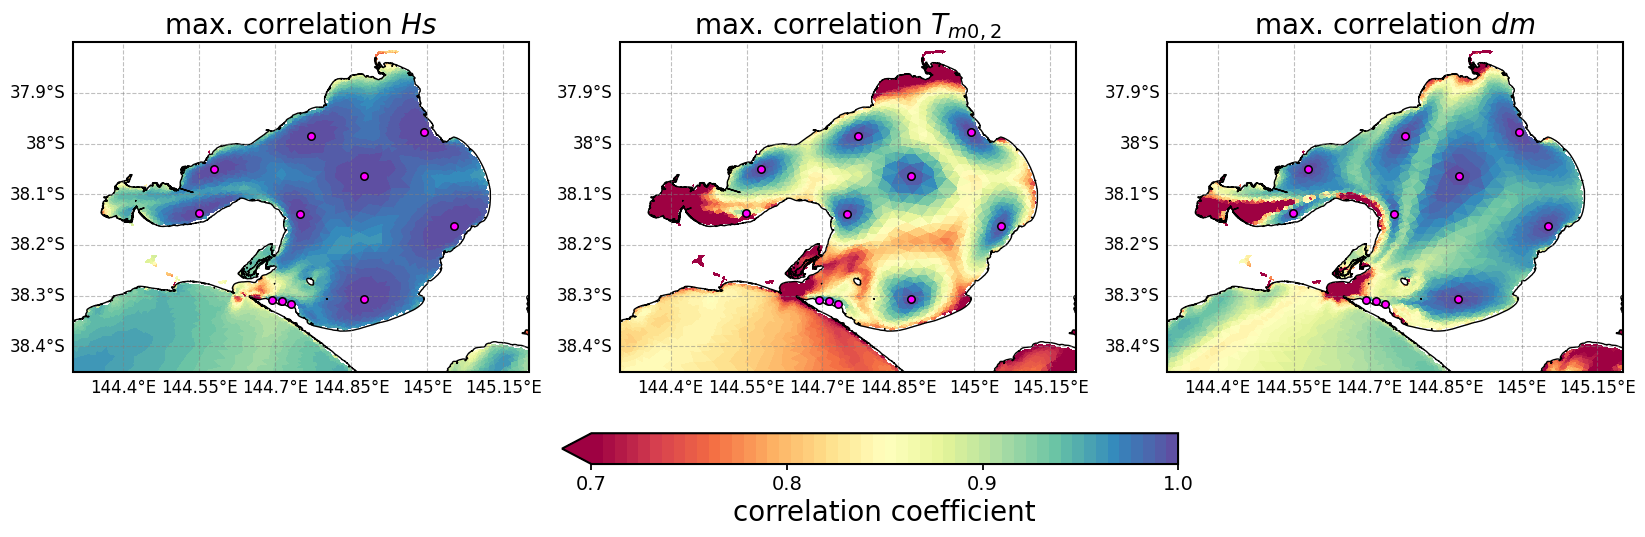

In [146]:
plt.clf()
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,8), subplot_kw={'projection': ccrs.PlateCarree()})
for ax in axs:
    for i in range(len(lons_coast)):
        ax.plot(lons_coast[i], lats_coast[i], color='black', lw=1.)
    ax.set_extent(extent_reg)
    gl = ax.gridlines(draw_labels=['bottom', 'left'], ls='--', color='grey', alpha=0.5)
    gl.xlabel_style = {'size':12}; gl.ylabel_style = {'size':12}
    ax.scatter(lons_buoys, lats_buoys, marker='o', color='black', s=30, zorder=2, transform=ccrs.PlateCarree())
    ax.scatter(lons_buoys, lats_buoys, marker='o', color='magenta', s=10, zorder=2, transform=ccrs.PlateCarree())

norm = mc.BoundaryNorm(np.linspace(0.7,1,51), 256)

ax = axs[0]
cax = ax.tripcolor(meshtri_reg, max_corr_hs[mask_nodes_reg], cmap='Spectral', norm=norm, transform=ccrs.PlateCarree())
ax.set_title('max. correlation $Hs$', size=20)

ax = axs[1]
cax = ax.tripcolor(meshtri_reg, max_corr_t02[mask_nodes_reg], cmap='Spectral', norm=norm, transform=ccrs.PlateCarree())
ax.set_title('max. correlation $T_{m0,2}$', size=20)

ax = axs[2]
cax = ax.tripcolor(meshtri_reg, max_corr_dm[mask_nodes_reg], cmap='Spectral', norm=norm, transform=ccrs.PlateCarree())
ax.set_title('max. correlation $dm$', size=20)

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=0.05, pad=0.1, extend='min', ticks=np.arange(0,1.1,0.1))
cbar.set_label('correlation coefficient', size=20)
cbar.minorticks_off()
cbar.ax.tick_params(size=4, width=1.3, labelsize=14)

plt.savefig(os.path.join(workdir, 'max_correlation_current_network_plus_KirkP_CliftonS.png'), bbox_inches='tight', dpi=300)